#Introducción


##Problema de Negocio y Objetivos:
El objetivo de este proyecto es desarrollar un modelo de clasificación de imágenes capaz de reconocer personajes de la serie animada "Los Simpson" utilizando técnicas de Deep Learning. El problema a resolver es de clasificación multiclase. Dado que las imágenes contienen alta variabilidad de fondos y posturas, se busca evaluar el desempeño de una arquitectura base de Perceptrón Multicapa (MLP).  
- KPIs del Proyecto: Se utilizarán métricas estándar de clasificación como Accuracy, Precision, Recall y F1-Score para evaluar la capacidad de generalización del modelo.  

- Variante del Proyecto: Para este estudio, se ha delimitado el problema a un subconjunto de 5 personajes específicos, limitando la cantidad de imágenes para evaluar el comportamiento de la red frente a conjuntos de datos reducidos

In [15]:
import os
import glob
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Flatten, BatchNormalization, MaxPooling2D, Input
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.metrics import confusion_matrix
from sklearn import metrics

import kagglehub

%matplotlib inline

In [16]:
#instalamos el data set:

# Download latest version
path = kagglehub.dataset_download("alfaro96/los-simpson")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\av-alumno\.cache\kagglehub\datasets\alfaro96\los-simpson\versions\5


In [17]:
import os

# Revisar qué carpetas o archivos hay en la ruta descargada
contenido = os.listdir(path)
print("Contenido descargado:", contenido)

Contenido descargado: ['test', 'train']


##Comprensión y exploración del conjunto de datos

###Análisis Exploratorio:
El dataset original de "Los Simpson" contiene 16137 imágenes RGB distribuidas en 25 clases con resoluciones variables. Al explorar los datos, se identificó un fuerte desbalance de clases. Por ejemplo, Homero Simpson cuenta con 1.796 imágenes, mientras que otros personajes tienen un número considerablemente menor.

Para evitar que el modelo genere un sesgo hacia la clase mayoritaria (Homero), se definió la siguiente estrategia:

***variable elegida:***

**personajes:**
- homero simpson (homer_simpson)
- ned flanders (ned_flanders)
- lisa simpson (lisa_simpson)
- bart simpson (bart_simpson)
- milhouse (milhouse_van_houten)

**Preparación y preprocesamiento de los datos**

- Balanceo y Muestreo: Se limitó el dataset a exactamente 100 imágenes por clase (500 imágenes en total), utilizando una semilla aleatoria fija (SEED = 67).
  
- Redimensionamiento: Todas las imágenes fueron redimensionadas a $64 \times 64$ píxeles para garantizar una entrada uniforme a la red.

- Normalización: Los valores de los píxeles (0-255) fueron escalados dividiéndolos por 255.0, dejándolos en el rango [0, 1] y facilitando la convergencia del algoritmo.  

- Partición de Datos: Se utilizó train_test_split con estratificación (stratify=y) para dividir los datos en un 80% para entrenamiento (400 imágenes) y un 20% para validación (100 imágenes).  




In [18]:


# 1. Definir la ruta a la carpeta de entrenamiento
train_dir = os.path.join(path, "train")
conteos = {}

# 2. Recorrer cada carpeta de personaje dentro de train
for personaje in sorted(os.listdir(train_dir)):
    ruta_personaje = os.path.join(train_dir, personaje)

    if os.path.isdir(ruta_personaje):
        # Contar archivos de imagen
        total = len([f for f in os.listdir(ruta_personaje) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        conteos[personaje] = total

# 3. Organizar en una tabla ordenada
df_conteos = pd.DataFrame(list(conteos.items()), columns=['Personaje', 'Cantidad_Imagenes'])
df_conteos = df_conteos.sort_values(by='Cantidad_Imagenes', ascending=False).reset_index(drop=True)

# 4. Calcular e imprimir métricas globales
total_imagenes = df_conteos['Cantidad_Imagenes'].sum()

print(f"Total de personajes encontrados: {len(df_conteos)}")
print(f"Total de imágenes encontradas: {total_imagenes}")

# 5. Mostrar los primeros 10
df_conteos.head(10)

Total de personajes encontrados: 25
Total de imágenes encontradas: 16137


,Personaje,Cantidad_Imagenes
0,homer_simpson,1796
1,ned_flanders,1163
2,moe_szyslak,1161
3,lisa_simpson,1083
4,bart_simpson,1073
5,marge_simpson,1032
6,krusty_the_clown,964
7,principal_skinner,955
8,charles_montgomery_burns,954
9,milhouse_van_houten,863


###Diseño del Perceptrón Multicapa (MLP)

Se implementó una red neuronal profunda base (MLP) mediante la API secuencial de Keras. La arquitectura consta de:

- Capa de Entrada (Flatten): Transforma la matriz de $64 \times 64 \times 3$ en un vector unidimensional de 12.288 características.  

- Capas Ocultas: Dos capas Densas de 128 y 64 neuronas respectivamente, ambas con función de activación ReLU para introducir no-linealidad.  

- Capa de Salida: Una capa Densa de 5 neuronas con activación Softmax, ideal para obtener una distribución de probabilidades en clasificación multiclase.  

- Hiperparámetros de Compilación: Se utilizó el optimizador Adam con una tasa de aprendizaje (learning_rate) de 0.001 y la función de pérdida sparse_categorical_crossentropy.  

- Justificación: El modelo genera un total de 1.581.573 parámetros entrenables. Esta enorme cantidad de parámetros para solo 400 imágenes de entrenamiento nos permitirá observar y documentar el fenómeno de sobreajuste (overfitting).  

In [19]:
# 1. Configuración de parámetros y reproducibilidad

import random
SEED = 67
np.random.seed(SEED)
random.seed(SEED)

tamaño_imagen = 64 #definimos un tamaño de imagen de 64 x 64
imagenes_personajes = 100 #seleccionamos 100 imagenes al azar por personajes

personajes_seleccionados = [
    'homer_simpson',
    'ned_flanders',
    'lisa_simpson',
    'bart_simpson',
    'milhouse_van_houten'
]

# Diccionario para mapear cada nombre a un número de clase (0 a 4)
etiqueta_map = {nombre: i for i, nombre in enumerate(personajes_seleccionados)}

X = []  # Lista para almacenar las matrices de píxeles de las imágenes
y = []  # Lista para almacenar las etiquetas correspondientes
train_dir = os.path.join(path, "train")

In [20]:
# 2. Carga, selección aleatoria y preprocesamiento
for personaje in personajes_seleccionados:
    ruta_personaje = os.path.join(train_dir, personaje)
    archivos = [f for f in os.listdir(ruta_personaje) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Seleccionamos exactamente 100 imágenes usando la semilla configurada
    archivos_elegidos = np.random.choice(archivos, size=imagenes_personajes, replace=False)

    for archivo in archivos_elegidos:
        ruta_img = os.path.join(ruta_personaje, archivo)
        img = cv2.imread(ruta_img)

        if img is not None:
            # OpenCV carga por defecto en formato BGR, lo convertimos a RGB estándar
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # Redimensionamos a 64x64
            img = cv2.resize(img, (tamaño_imagen,tamaño_imagen))
            # Normalizamos dividiendo por 255.0
            img = img.astype('float32') / 255.0

            X.append(img)
            y.append(etiqueta_map[personaje])

# Convertir listas a arreglos de NumPy
X = np.array(X)
y = np.array(y)

print(f"Forma de X (imágenes): {X.shape}")
print(f"Forma de y (etiquetas): {y.shape}")

Forma de X (imágenes): (500, 64, 64, 3)
Forma de y (etiquetas): (500,)


**Definimos el total de imagenes a entrenar y el total de imagenes para validar. para este caso utilizamos un 80% para entrenar y un 20% para realizar pruebas**

In [21]:
from sklearn.model_selection import train_test_split

# Dividir en 80% entrenamiento y 20% prueba/validación
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f"Imágenes de entrenamiento: {X_train.shape[0]}")
print(f"Imágenes de prueba/validación: {X_test.shape[0]}")

Imágenes de entrenamiento: 400
Imágenes de prueba/validación: 100


**utilizamos la funcion de Softmax para que tome los numeros entregados por las 5 neuronas de salida y las transforme en probabilidades**

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# 1. Definir la arquitectura MLP
model = Sequential([
    Flatten(input_shape=(tamaño_imagen, tamaño_imagen, 3)), # Entrada aplanada
    Dense(128, activation='relu'),                # Primera capa oculta
    Dense(64, activation='relu'),                 # Segunda capa oculta
    Dense(5, activation='softmax')                # Capa de salida para las 5 clases
])

# 2. Visualizar la estructura y número de parámetros
model.summary()

c:\Users\av-alumno\Downloads\SimpsonDatabase\env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,573 (6.03 MB)

 Trainable params: 1,581,573 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
from tensorflow.keras.optimizers import Adam

# Compilar el modelo
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("¡Modelo compilado exitosamente!")

¡Modelo compilado exitosamente!


##Entrenamiento del modelo

El modelo fue entrenado durante 30 épocas utilizando un tamaño de lote (batch_size) de 32.
Al analizar las curvas de aprendizaje obtenidas

- Entrenamiento: La función de pérdida (loss) disminuyó constantemente hasta alcanzar 0.2088, mientras que la precisión (accuracy) subió hasta un excelente 98.25% en la época 30.  

- Validación: A partir de la época 4 o 5, la pérdida de validación dejó de disminuir y comenzó a subir abruptamente hasta 1.9075, estancando su exactitud en un 38.00%.

- Análisis del comportamiento: Estas curvas son el síntoma clásico de sobreajuste (overfitting). Al tener más de 1.5 millones de parámetros y pocas imágenes, el modelo memorizó los datos de entrenamiento en lugar de extraer patrones generales.  

In [24]:
# Entrenamos durante 30 épocas con lotes de 32
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1975 - loss: 3.3456 - val_accuracy: 0.2400 - val_loss: 1.8476
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2775 - loss: 1.7367 - val_accuracy: 0.4100 - val_loss: 1.9615
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3400 - loss: 1.6606 - val_accuracy: 0.3200 - val_loss: 1.7379
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3650 - loss: 1.5532 - val_accuracy: 0.3100 - val_loss: 1.5630
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4700 - loss: 1.3032 - val_accuracy: 0.2800 - val_loss: 1.6316
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4775 - loss: 1.3081 - val_accuracy: 0.4300 - val_loss: 2.0307
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5325 - loss: 1.2863 - val_accuracy: 0.3400 - val_loss: 1.6573
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5750 - loss: 1.1195 - val_accuracy: 0.4200 - v

##Evaluación del desempeño

La evaluación final sobre el conjunto de prueba (100 imágenes) arrojó las siguientes métricas:  

- Accuracy Global: 38%.  Precision, Recall y F1-Score:Mejor desempeño: homer_simpson obtuvo la mejor métrica combinada, con un F1-Score de 0.59 (Precision 0.65, Recall 0.55), logrando identificar correctamente 11 de sus 20 imágenes.  

- Peor desempeño: lisa_simpson y bart_simpson obtuvieron las métricas más bajas, ambos con un F1-Score de 0.22 (Precision 0.20, Recall 0.25).  

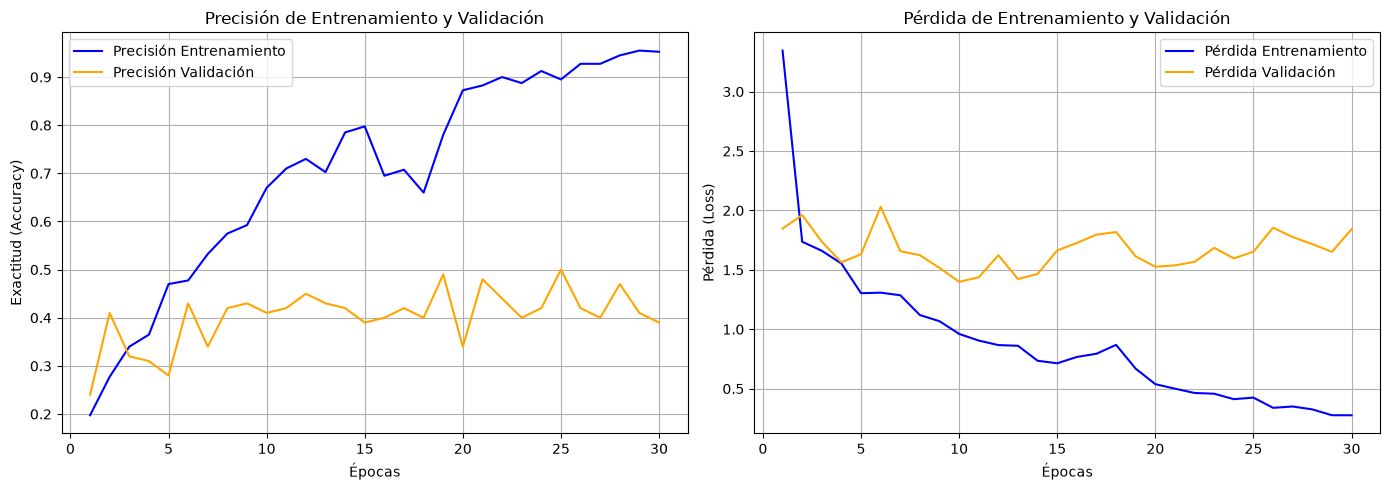

In [25]:
import matplotlib.pyplot as plt

# Extraer métricas del historial
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Crear los gráficos
plt.figure(figsize=(14, 5))

# 1. Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión Entrenamiento', color='blue')
plt.plot(epochs_range, val_acc, label='Precisión Validación', color='orange')
plt.title('Precisión de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Exactitud (Accuracy)')
plt.legend()
plt.grid(True)

# 2. Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida Entrenamiento', color='blue')
plt.plot(epochs_range, val_loss, label='Pérdida Validación', color='orange')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Loss)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
--- REPORTE DE CLASIFICACIÓN ---
                     precision    recall  f1-score   support

      homer_simpson       0.46      0.90      0.61        20
       ned_flanders       0.44      0.40      0.42        20
       lisa_simpson       0.40      0.10      0.16        20
       bart_simpson       0.21      0.30      0.24        20
milhouse_van_houten       0.56      0.25      0.34        20

           accuracy                           0.39       100
          macro avg       0.41      0.39      0.36       100
       weighted avg       0.41      0.39      0.36       100



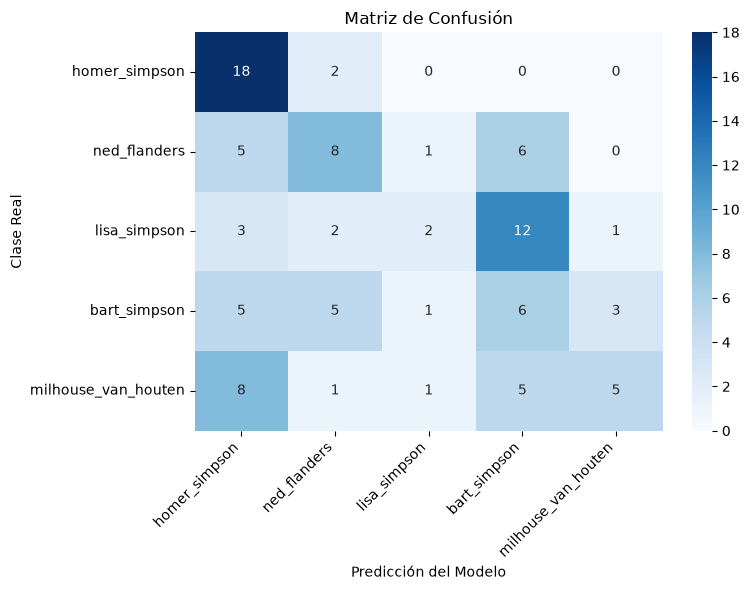

In [26]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Obtener las predicciones del modelo sobre los datos de validación
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Reporte de clasificación (Precision, Recall, F1-score)
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=personajes_seleccionados))

# 3. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=personajes_seleccionados,
            yticklabels=personajes_seleccionados)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#grafico de errores

In [ ]:
#Obtener las predicciones del modelo
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

#Obtener las etiquetas reales (si y_test está en formato One-Hot Encoding)
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

print("Forma de y_pred:", y_pred.shape)
print("Forma de y_true:", y_true.shape)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Forma de y_pred: (100,)
Forma de y_true: (100,)


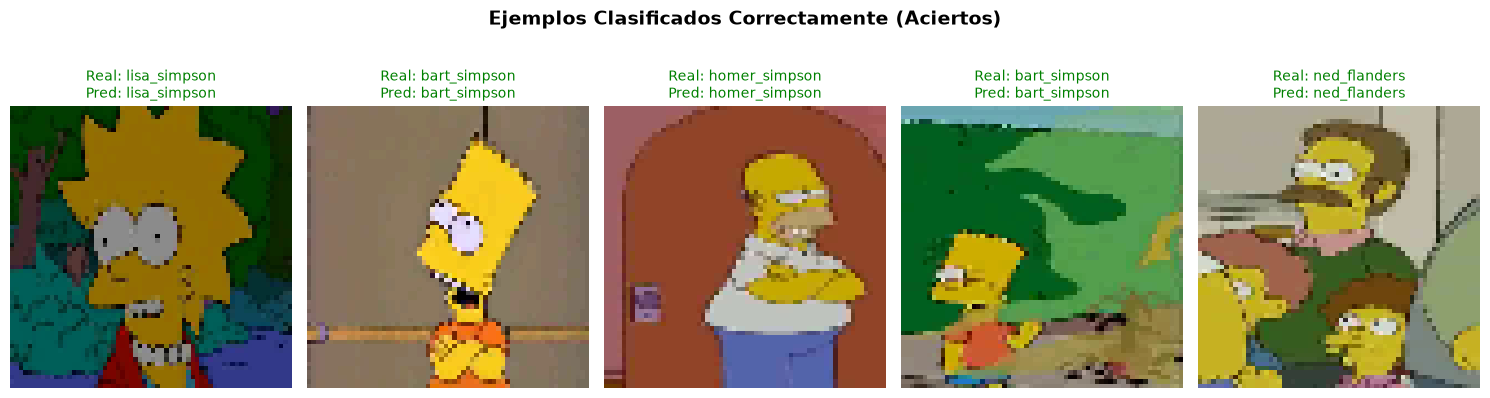

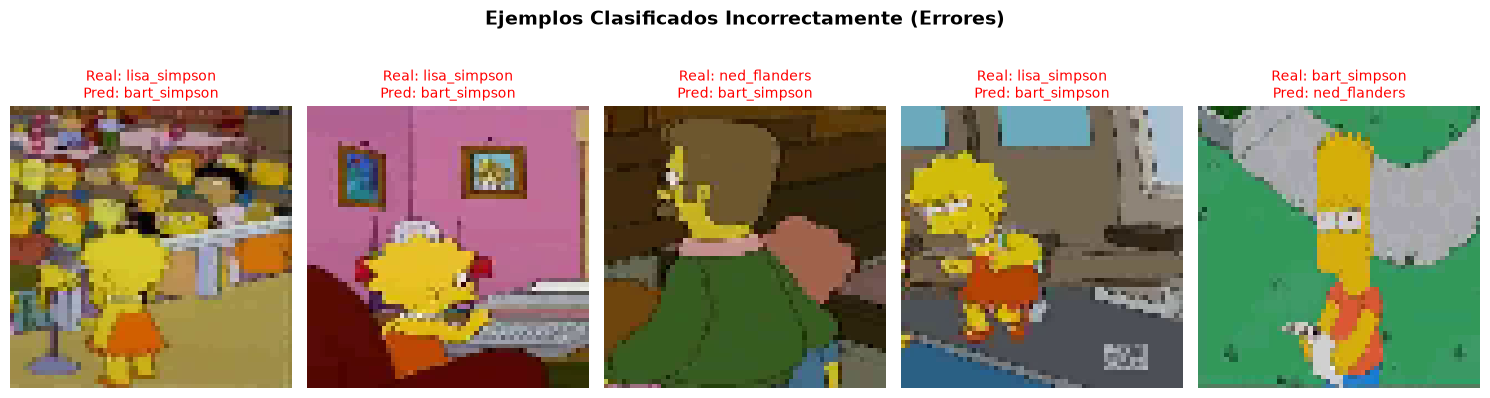

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Identificar índices de aciertos y errores
correctos = np.where(y_pred == y_true)[0]
incorrectos = np.where(y_pred != y_true)[0]

# 2. Función para graficar las imágenes
def mostrar_galeria(indices, titulo, cantidad=5):
    plt.figure(figsize=(15, 4))
    for i, idx in enumerate(indices[:cantidad]):
        plt.subplot(1, cantidad, i + 1)

        # Desplegar la imagen de prueba
        plt.imshow(X_test[idx])
        plt.axis('off')

        clase_real = personajes_seleccionados[y_true[idx]]
        clase_pred = personajes_seleccionados[y_pred[idx]]

        # Color verde para aciertos, rojo para errores
        es_correcto = clase_real == clase_pred
        color = 'green' if es_correcto else 'red'

        plt.title(f"Real: {clase_real}\nPred: {clase_pred}", color=color, fontsize=10)

    plt.suptitle(titulo, fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# 3. Visualizar 5 ejemplos de cada caso
mostrar_galeria(correctos, "Ejemplos Clasificados Correctamente (Aciertos)", cantidad=5)
mostrar_galeria(incorrectos, "Ejemplos Clasificados Incorrectamente (Errores)", cantidad=5)

##Análisis de resultados y errores

Al revisar la Matriz de Confusión y las métricas, se identifican las principales debilidades de la clasificación:

- Clases con mayor confusión: Existe una alta tasa de error al clasificar a Bart y Lisa.  

- Causas de la predicción errónea: Visualmente, Bart y Lisa comparten la misma paleta de colores (amarillo continuo entre piel y cabello, tonos cálidos en la ropa) y proporciones similares. Al utilizar una capa Flatten al inicio del MLP, la imagen pierde toda su estructura espacial 2D y geometría (como la diferencia entre los picos del pelo de Bart y la forma de estrella de Lisa), convirtiéndose solo en una secuencia de colores. Homero y Ned Flanders, al tener paletas de color más contrastantes (barba marrón, suéter verde), son más fáciles de clasificar para este tipo de red.  

##Conclusiones

- Desempeño y Limitaciones: Se demostró que un modelo Perceptrón Multicapa (MLP) puro presenta graves limitaciones para tareas complejas de visión artificial. Su principal debilidad es la pérdida de la topología de la imagen debido a la capa Flatten, lo que fuerza a crear conexiones densas que disparan el número de parámetros (más de 1.5 millones), facilitando la memorización y el overfitting.
  
- Mejoras propuestas: Para futuras iteraciones de este proyecto, se propone reemplazar la arquitectura MLP por Redes Neuronales Convolucionales (CNN). La incorporación de capas Conv2D permitiría extraer patrones geométricos y contornos sin perder la estructura espacial, reduciendo drásticamente la cantidad de parámetros y mejorando la capacidad de generalización del modelo en imágenes no vistas.  